In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 64), 
            nn.ReLU(),
            nn.Dropout(0.6),  
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
def load_model(model_path, device='cpu'):
    model = CNN()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()  # Переводим в режим оценки
    return model

In [ ]:
def preprocess_image(image_path, img_size=150):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

    image = Image.open(image_path).convert('RGB')
    original_image = image.copy()
    
    # Применяем трансформации
    input_tensor = transform(image)
    input_batch = input_tensor.unsqueeze(0)  # Добавляем еще размерность
    
    return input_batch, original_image

In [12]:
def predict_image(model, image_tensor, device='cpu', threshold=0.5):
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        output = model(image_tensor)
        probability = output.item()
        
        # Определяем класс
        if probability > threshold:
            predicted_class = "human"
        else:
            predicted_class = "horse"
            
        return predicted_class

In [13]:
def visualize_prediction(image, prediction):
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    
    title = f"Prediction: {prediction}"
    plt.title(title, color='white')
    plt.tight_layout()
    plt.show()

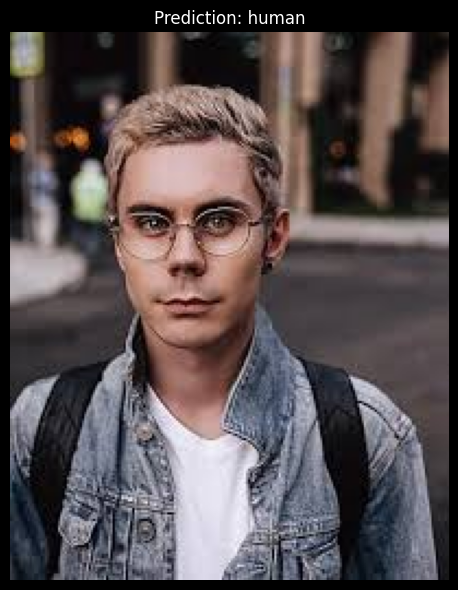

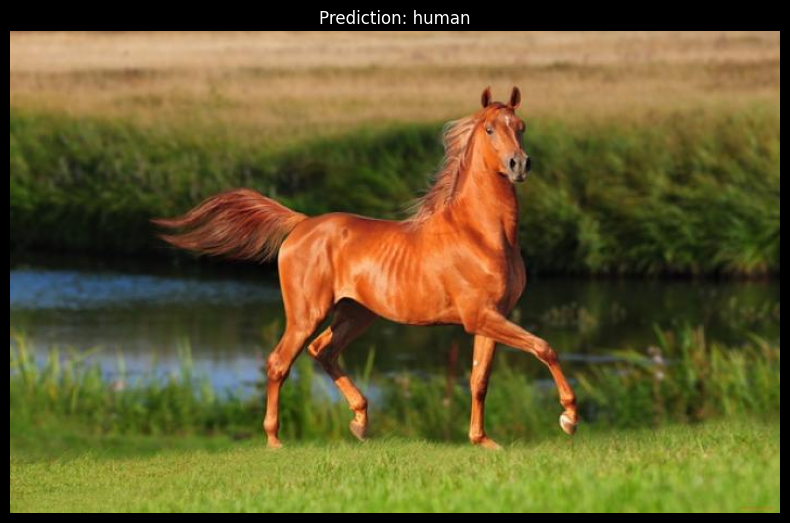

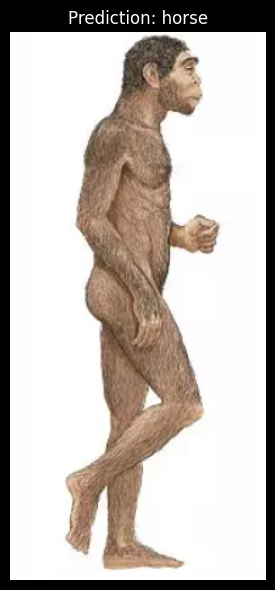

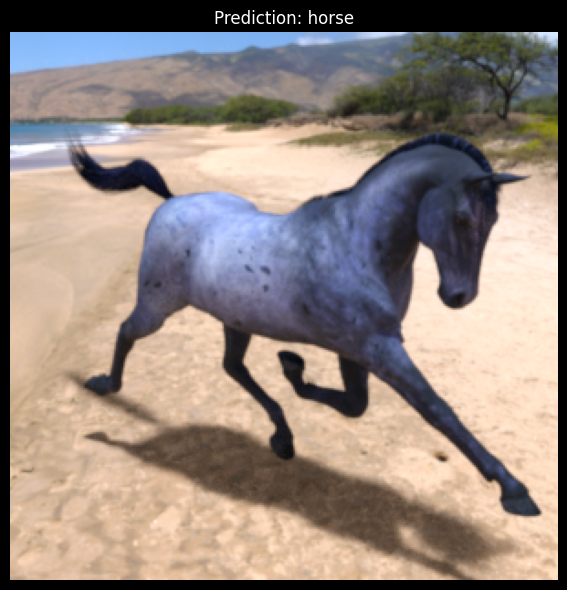

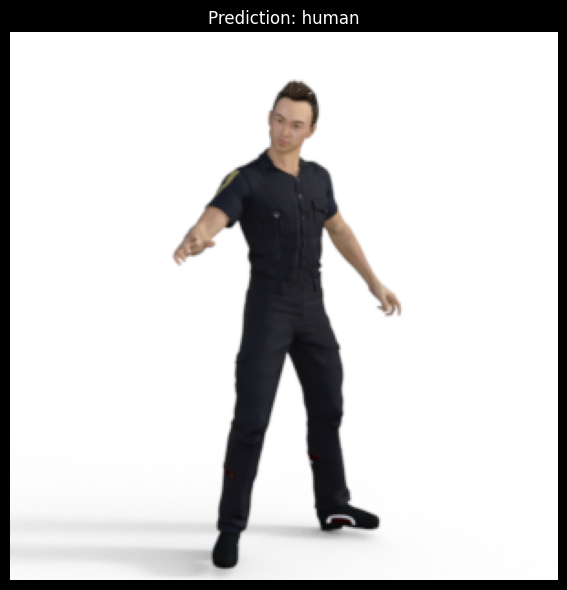

In [14]:
MODEL_PATH = 'model.pth'
IMAGES = [
    '1.jfif', '2.jpg', '5.png', '6.png', '7.png'
]

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Загружаем модель
model = load_model(MODEL_PATH, device)


for image_path in IMAGES:
    # Предобрабатываем изображение
    image_tensor, original_image = preprocess_image('img/' + image_path)

    # Делаем предсказание
    predicted_class = predict_image(model, image_tensor, device)

    # Визуализируем
    visualize_prediction(original_image, predicted_class)